<a href="https://colab.research.google.com/github/shubham3032002/flower-classification-using-transfer-learning/blob/main/flowers_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
import shutil
# Download latest version

savepath=('/content/dataset')
path = kagglehub.dataset_download("imsparsh/flowers-dataset")
shutil.move(path,savepath)
print("Path to dataset files:", savepath)

100%|██████████| 205M/205M [00:01<00:00, 181MB/s]

Extracting files...


Path to dataset files: /content/dataset


In [1]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom
from sklearn.model_selection import train_test_split

In [2]:
from tensorflow.keras.utils import image_dataset_from_directory

dataset_path='/content/dataset'
batch_size=32
img_size=(224,224)



In [3]:
# Load the train dataset
train_dataset = image_dataset_from_directory(
    dataset_path + '/train',
    label_mode='categorical',
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True  # Shuffle to ensure randomness
)



Found 2746 files belonging to 5 classes.


In [4]:
dataset_list=list(train_dataset.as_numpy_iterator())
images, labels = zip(*dataset_list)

In [5]:
images = np.concatenate(images, axis=0)
labels = np.concatenate(labels, axis=0)

In [6]:
# Split data into training and validation sets (80% train, 20% validation)
train_images, val_images, train_labels, val_labels = train_test_split(
    images, labels, test_size=0.2, random_state=42
)

In [7]:
train_dataset=tf.data.Dataset.from_tensor_slices((train_images,train_labels))
val_dataset=tf.data.Dataset.from_tensor_slices((val_images,val_labels))


In [8]:
# Data Augmentation
data_augmentation = tf.keras.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.2),
    RandomZoom(0.2),
])


In [9]:
def preprocess_image(image, label):
    image = tf.cast(image, tf.float32) / 255.0  # Normalize to [0, 1]
    return image, label


In [10]:
# Recreate datasets with batching
train_dataset = tf.data.Dataset.from_tensor_slices((train_images, train_labels)) \
    .map(preprocess_image) \
    .batch(batch_size) \
    .prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((val_images, val_labels)) \
    .map(preprocess_image) \
    .batch(batch_size) \
    .prefetch(tf.data.AUTOTUNE)

In [11]:
# Load the pre-trained EfficientNetB0 model
base_model = tf.keras.applications.EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)


In [12]:
base_model.trainable=False

In [13]:
#add custom layers on top of the pre-trained model
inputs = tf.keras.Input(shape=(224, 224, 3))
x=data_augmentation(inputs)
x=base_model(x,training=False)
x=GlobalAveragePooling2D()(x)
x=Dropout(0.2)(x)
outputs = Dense(train_labels.shape[1], activation='softmax')(x)  # Number of classes
model = Model(inputs, outputs)

In [14]:

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
# Train the model
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10
)


Epoch 1/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 25s 150ms/step - accuracy: 0.2019 - loss: 1.6369 - val_accuracy: 0.2382 - val_loss: 1.6078
Epoch 2/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 13s 95ms/step - accuracy: 0.2188 - loss: 1.6269 - val_accuracy: 0.2382 - val_loss: 1.6069
Epoch 3/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 6s 90ms/step - accuracy: 0.2289 - loss: 1.6306 - val_accuracy: 0.2382 - val_loss: 1.6036
Epoch 4/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 6s 92ms/step - accuracy: 0.2287 - loss: 1.6199 - val_accuracy: 0.2400 - val_loss: 1.6037
Epoch 5/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 10s 93ms/step - accuracy: 0.2206 - loss: 1.6251 - val_accuracy: 0.2382 - val_loss: 1.6044
Epoch 6/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 10s 92ms/step - accuracy: 0.2446 - loss: 1.6244 - val_accuracy: 0.2382 - val_loss: 1.6039
Epoch 7/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 10s 92ms/step - accuracy: 0.2314 - loss: 1.6228 - val_accuracy: 0.2382 - val_loss: 1.6046
Epoch 8/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 6s 94ms/step - accuracy: 0.2224 - loss: 1.6249 - val_accuracy: 0.23

In [16]:
# Fine-tune the model
base_model.trainable = True  # Unfreeze the base model

In [17]:
# Recompile with a lower learning rate for fine-tuning
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
# Fine-tune
fine_tune_epochs = 10
total_epochs = 10 + fine_tune_epochs
history_fine = model.fit(
    train_dataset,
    validation_data=val_dataset,
    initial_epoch=history.epoch[-1],
    epochs=total_epochs
)

Epoch 10/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 71s 382ms/step - accuracy: 0.4531 - loss: 1.3135 - val_accuracy: 0.2255 - val_loss: 1.6681
Epoch 11/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 38s 347ms/step - accuracy: 0.8266 - loss: 0.5511 - val_accuracy: 0.2255 - val_loss: 1.7082
Epoch 12/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 41s 348ms/step - accuracy: 0.8843 - loss: 0.3396 - val_accuracy: 0.1382 - val_loss: 1.7203
Epoch 13/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 41s 347ms/step - accuracy: 0.9125 - loss: 0.2554 - val_accuracy: 0.1818 - val_loss: 1.6646
Epoch 14/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 41s 347ms/step - accuracy: 0.9315 - loss: 0.1978 - val_accuracy: 0.5491 - val_loss: 1.2201
Epoch 15/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 41s 350ms/step - accuracy: 0.9468 - loss: 0.1501 - val_accuracy: 0.6273 - val_loss: 1.0549
Epoch 16/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 41s 348ms/step - accuracy: 0.9546 - loss: 0.1324 - val_accuracy: 0.4909 - val_loss: 1.6210
Epoch 17/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 24s 350ms/step - accuracy: 0.9720 - loss: 0.0858 - 

In [19]:
# Evaluate on validation dataset
loss, accuracy = model.evaluate(val_dataset)
print(f"Validation Accuracy: {accuracy * 100:.2f}%")

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.6422 - loss: 0.8506
Validation Accuracy: 67.09%


In [20]:
# Save the trained model
model.save('flower_classifier.h5')

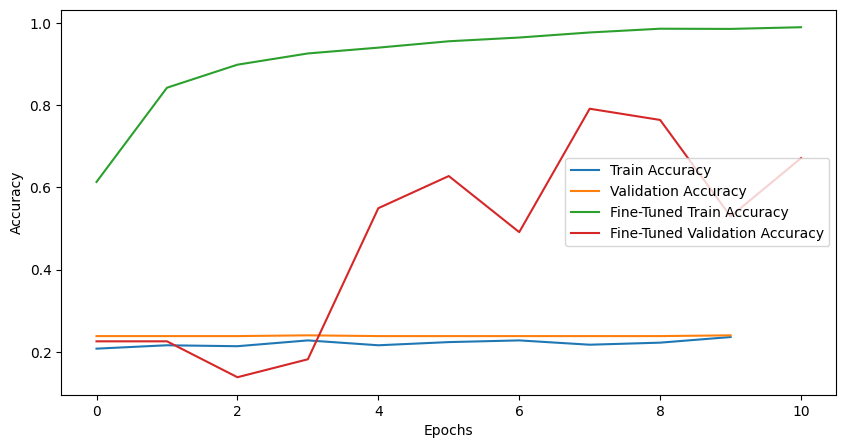

In [22]:

# Plot training history
def plot_history(history, fine_history=None):
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    if fine_history:
        plt.plot(fine_history.history['accuracy'], label='Fine-Tuned Train Accuracy')
        plt.plot(fine_history.history['val_accuracy'], label='Fine-Tuned Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

plot_history(history, history_fine)



In [23]:
# Load and predict on a new image
from tensorflow.keras.utils import load_img, img_to_array


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


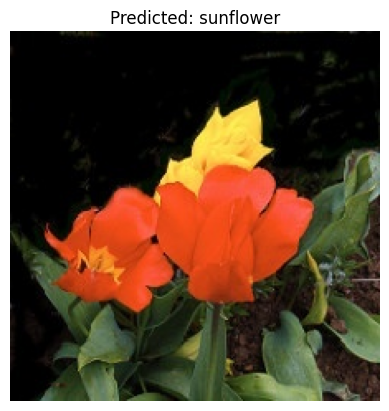

In [37]:
import os
import random
import matplotlib.pyplot as plt
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np

# Define the category names
categories = ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']

# Get a random image from the directory
test_dir = '/content/dataset/test'
random_image = random.choice(os.listdir(test_dir))  # Randomly select an image
img_path = os.path.join(test_dir, random_image)  # Full path to the image

# Load and preprocess the image
img = load_img(img_path, target_size=(224, 224))  # Match model's input size
img_array = img_to_array(img) / 255.0
img_array = tf.expand_dims(img_array, axis=0)  # Add batch dimension

# Predict
predictions = model.predict(img_array)
predicted_class = np.argmax(predictions)
predicted_label = categories[predicted_class]  # Get the category name

# Display the image and prediction
plt.imshow(img)
plt.axis('off')
plt.title(f"Predicted: {predicted_label}")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


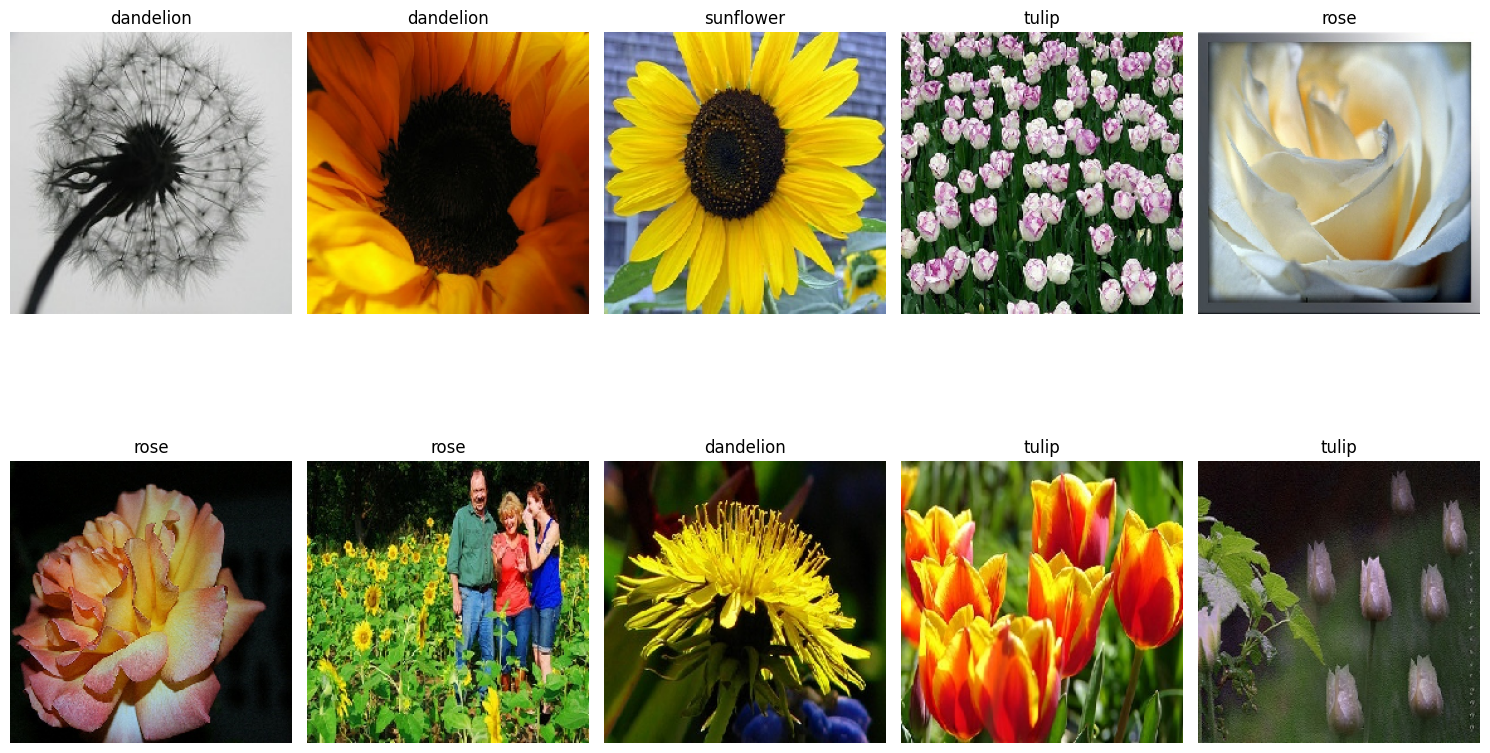

In [43]:
import os
import random
import matplotlib.pyplot as plt
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np

# Define the category names
categories = ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']

# Get 10 random images from the directory
test_dir = '/content/dataset/test'
image_files = random.sample(os.listdir(test_dir), 10)  # Randomly select 10 images

# Prepare the plot
plt.figure(figsize=(15, 10))

for i, image_file in enumerate(image_files):
    img_path = os.path.join(test_dir, image_file)  # Full path to the image

    # Load and preprocess the image
    img = load_img(img_path, target_size=(224, 224))  # Match model's input size
    img_array = img_to_array(img) / 255.0
    img_array = tf.expand_dims(img_array, axis=0)  # Add batch dimension

    # Predict
    predictions = model.predict(img_array)
    predicted_class = np.argmax(predictions)
    predicted_label = categories[predicted_class]  # Get the category name

    # Display the image and prediction
    plt.subplot(2, 5, i + 1)  # Arrange in a 2x5 grid
    plt.imshow(img)
    plt.axis('off')
    plt.title(predicted_label)

plt.tight_layout()
plt.show()


Enter the path to your image: /content/download.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


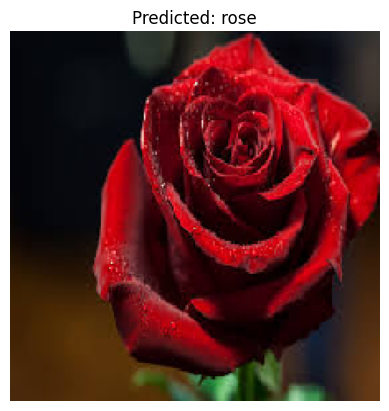

Predicted Category: rose


In [42]:
import matplotlib.pyplot as plt
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import tensorflow as tf

# Define the category names
categories = ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']

# Function to predict and display the result
def predict_flower(image_path, model, categories):
    try:
        # Load and preprocess the image
        img = load_img(image_path, target_size=(224, 224))  # Match model's input size
        img_array = img_to_array(img) / 255.0
        img_array = tf.expand_dims(img_array, axis=0)  # Add batch dimension

        # Predict
        predictions = model.predict(img_array)
        predicted_class = np.argmax(predictions)
        predicted_label = categories[predicted_class]  # Get the category name

        # Display the image and prediction
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Predicted: {predicted_label}")
        plt.show()

        print(f"Predicted Category: {predicted_label}")

    except Exception as e:
        print(f"Error: {e}")

# Provide the path to your image
image_path = input("Enter the path to your image: ")

# Call the function to predict
predict_flower(image_path, model, categories)
